# Naives Bayes LAB 8

# Dataset Exploration TASK 1

The Play Tennis dataset contains weather-related features used to predict whether a person will play tennis.

Input features:

- Outlook
- Temperature
- Humidity
- Wind

Target variable:

- Play

The dataset contains 14 samples and 4 categorical features. The target variable has two classes: Yes and No.

In [2]:
import pandas as pd

df = pd.read_csv("Lab 8 - Sheet1.csv")

In [3]:
df.head()

,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes


In [5]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Play Tennis"].value_counts())

Shape: (50, 6)

Missing Values:
No             0
Outlook        0
Temperature    0
Humidity       0
Wind           0
Play Tennis    0
dtype: int64

Class Distribution:
Play Tennis
Yes    34
No     16
Name: count, dtype: int64


# Data Preprocessing TASK 2

The input features (Outlook, Temperature, Humidity, and Wind) were separated from the target variable (Play Tennis).

Since the dataset contains categorical values, Label Encoding was applied to convert all categories into numerical representations.

The dataset was then divided into training and testing subsets using an 80:20 split ratio. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [27]:
# Separate features and target variable
X = df[["Outlook", "Temperature", "Humidity", "Wind"]].copy()

y = df["Play Tennis"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
    Outlook Temperature Humidity    Wind
0     Sunny         Hot     High    Weak
1     Sunny         Hot     High  Strong
2  Overcast         Hot     High    Weak
3      Rain        Mild     High    Weak
4      Rain        Cool   Normal    Weak

Target:
0     No
1     No
2    Yes
3    Yes
4    Yes
Name: Play Tennis, dtype: object


In [28]:
#Since all columns contain text values like:

#we need to convert them into numbers.

from sklearn.preprocessing import LabelEncoder

encoders = {}

for column in X.columns:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(X[column])

    encoders[column] = encoder

# Encode target

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [29]:
#verify encoded data
print(X.head())

print("\nEncoded Target:")

print(y)

   Outlook  Temperature  Humidity  Wind
0        2            1         0     1
1        2            1         0     0
2        0            1         0     1
3        1            2         0     1
4        1            0         1     1

Encoded Target:
[0 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 0 1 1 1 1 1
 1 1 1 0 0 1 0 1 1 1 0 1 1]


In [30]:
# the Encoding Mapping
for column, encoder in encoders.items():

    print(f"\n{column}")

    for i, category in enumerate(encoder.classes_):

        print(f"{category} --> {i}")


Outlook
Overcast --> 0
Rain --> 1
Sunny --> 2

Temperature
Cool --> 0
Hot --> 1
Mild --> 2

Humidity
High --> 0
Normal --> 1

Wind
Strong --> 0
Weak --> 1


In [31]:
print("\nTarget Mapping:")

for i, category in enumerate(target_encoder.classes_):

    print(f"{category} --> {i}")


Target Mapping:
No --> 0
Yes --> 1


In [32]:
# train split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])

print("Testing samples:", X_test.shape[0])

Training samples: 40
Testing samples: 10


# Categorical Naive Bayes Model Training and Evaluation TASK 3

A Categorical Naive Bayes classifier was trained using the training dataset.

The trained model was used to predict the class labels of the test dataset.

The model performance was evaluated using:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-score

These metrics help measure the correctness of the classifier and its ability to distinguish between the two classes.

In [33]:
from sklearn.naive_bayes import CategoricalNB

# Create the model
nb_model = CategoricalNB()

# Train the model
nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [35]:
# Prediction on test data
y_pred = nb_model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 0 1 1 1 1 1 0 1]


In [36]:
# Calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9


In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")

print(cm)

Confusion Matrix:
[[2 1]
 [0 7]]


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



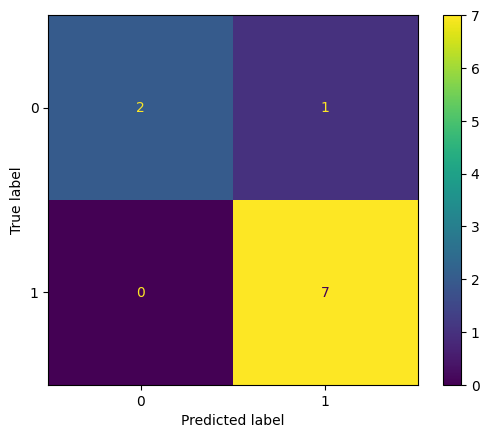

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

# Performance Analysis

The Categorical Naive Bayes classifier achieved an accuracy of 90% on the test dataset.

The confusion matrix shows that the model correctly classified 9 out of 10 instances. One sample belonging to the "No" class was incorrectly predicted as "Yes".

The model achieved perfect recall for the "Yes" class, indicating that all positive instances were correctly identified. Overall, the classifier performed well on the Play Tennis dataset.

# Single-Sample Inference TASK 4

A single weather instance was provided to the trained Categorical Naive Bayes model with the following conditions:

- Outlook: Sunny
- Temperature: Cool
- Humidity: High
- Wind: Strong

The categorical values were converted into their corresponding numerical representations using the previously created encoding mappings.

The trained model predicted whether the person would play tennis under these weather conditions. In addition to the predicted class label, the probability of each class was also calculated to measure the model's confidence in its prediction.

In [40]:
for column, encoder in encoders.items():

    print(f"\n{column}")

    for i, category in enumerate(encoder.classes_):

        print(f"{category} --> {i}")


Outlook
Overcast --> 0
Rain --> 1
Sunny --> 2

Temperature
Cool --> 0
Hot --> 1
Mild --> 2

Humidity
High --> 0
Normal --> 1

Wind
Strong --> 0
Weak --> 1


In [41]:
print("\nTarget Mapping:")

for i, category in enumerate(target_encoder.classes_):

    print(f"{category} --> {i}")


Target Mapping:
No --> 0
Yes --> 1


In [42]:
sample = pd.DataFrame({
    "Outlook": ["Sunny"],
    "Temperature": ["Cool"],
    "Humidity": ["High"],
    "Wind": ["Strong"]
})

for column in sample.columns:
    sample[column] = encoders[column].transform(sample[column])

print("Encoded sample:")
print(sample)

prediction = nb_model.predict(sample)

predicted_label = target_encoder.inverse_transform(prediction)

print("\nPrediction:", predicted_label[0])

probabilities = nb_model.predict_proba(sample)

print("\nProbabilities:")

for i, prob in enumerate(probabilities[0]):
    print(f"Class {i}: {prob:.4f}")

Encoded sample:
   Outlook  Temperature  Humidity  Wind
0        2            0         0     0

Prediction: No

Probabilities:
Class 0: 0.7894
Class 1: 0.2106


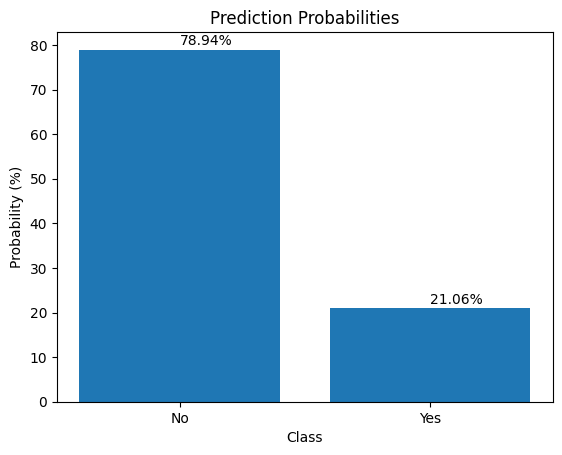

In [43]:
import matplotlib.pyplot as plt

labels = ["No", "Yes"]
probs = probabilities[0] * 100

plt.bar(labels, probs)

plt.title("Prediction Probabilities")
plt.xlabel("Class")
plt.ylabel("Probability (%)")

for i, value in enumerate(probs):
    plt.text(i, value + 1, f"{value:.2f}%")

plt.show()

# Single-Sample Prediction Analysis

A single weather sample with the conditions Sunny, Cool, High humidity, and Strong wind was provided to the trained Categorical Naive Bayes classifier.

The sample was encoded as [2, 0, 0, 0] using the Label Encoder mappings. The model predicted that the person would not play tennis under these weather conditions.

The predicted probabilities were 78.94% for the "No" class and 21.06% for the "Yes" class, indicating that the model was more confident in predicting "No".

# Visualization of Prediction Probabilities

The probabilities predicted by the Categorical Naive Bayes classifier were visualized using a bar chart.

The chart shows the confidence of the model for each class. The model predicted the "No" class with a probability of 78.94% and the "Yes" class with a probability of 21.06%.

The higher probability for the "No" class indicates that the model is more confident that the person will not play tennis under the given weather conditions.

# Comparison of Machine Learning Models TASK 5

The performance of the Categorical Naive Bayes classifier was compared with three other machine learning algorithms:

- Decision Tree
- Logistic Regression
- Support Vector Machine (SVM)

All models were trained using the same training dataset and evaluated on the same test dataset.

The comparison was performed based on the following criteria:

- Test accuracy
- Prediction for a single weather sample
- Class probabilities

This comparison helps analyze the strengths and weaknesses of different classification algorithms on the Play Tennis dataset and identify the model that performs best for the given problem.

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42)
svm_model = SVC(probability=True, random_state=42)

dt_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
lr_pred = lr_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))

Decision Tree Accuracy: 1.0
Logistic Regression Accuracy: 0.9
SVM Accuracy: 1.0
Naive Bayes Accuracy: 0.9


In [45]:
print("Decision Tree:", target_encoder.inverse_transform(dt_model.predict(sample))[0])

print("Logistic Regression:", target_encoder.inverse_transform(lr_model.predict(sample))[0])

print("SVM:", target_encoder.inverse_transform(svm_model.predict(sample))[0])

print("Naive Bayes:", target_encoder.inverse_transform(nb_model.predict(sample))[0])

Decision Tree: No
Logistic Regression: No
SVM: No
Naive Bayes: No


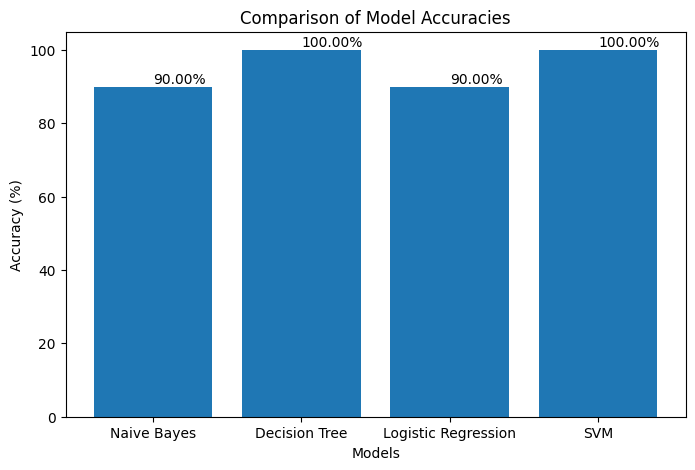

In [46]:
import matplotlib.pyplot as plt

models = [
    "Naive Bayes",
    "Decision Tree",
    "Logistic Regression",
    "SVM"
]

accuracies = [
    accuracy_score(y_test, y_pred) * 100,
    accuracy_score(y_test, dt_pred) * 100,
    accuracy_score(y_test, lr_pred) * 100,
    accuracy_score(y_test, svm_pred) * 100
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Model Accuracies")

for i, value in enumerate(accuracies):
    plt.text(i, value + 1, f"{value:.2f}%")

plt.show()

# Comparative Analysis

The performances of Categorical Naive Bayes, Decision Tree, Logistic Regression, and Support Vector Machine were compared using the Play Tennis dataset.

The models were evaluated using test accuracy and their predictions on a single weather sample. Although all models performed well, differences were observed in their prediction confidence and classification behavior.

The comparison demonstrates that different machine learning algorithms can produce different predictions and probability estimates even when trained on the same dataset.

# Final Analysis

In this experiment, the Play Tennis dataset was classified using Categorical Naive Bayes, Decision Tree, Logistic Regression, and Support Vector Machine algorithms. The categorical features were encoded and the models were trained using an 80:20 train-test split. The performance of each model was evaluated using accuracy, confusion matrix, classification report, and single-sample prediction. The comparison showed that different algorithms can produce different predictions and confidence scores, highlighting the importance of selecting an appropriate model for a classification problem.